In [58]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import cmocean.cm as cmo

import numpy as np
from scipy.special import logsumexp
import torch
# from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.plots import plotting_fes_db


from flonacomldft.collective_variables import get_CVs, compute_C, compute_R
from flonacomldft.utils.io_utils import get_path, load_pickle_file, load_csv_file
from flonacomldft.models.mixture import get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

In [7]:
data_path = get_path()
data_path

'/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/'

In [8]:
mode_labels = [0, 1]
flows_dic = [load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]

# trained'
flows = get_models(flows_dic)
mlps = get_models(mlps_dic) 

In [13]:
coord_mapping = Coordinates_mapping() 


mode_labels = [0, 1]
dataset_label = 'md_train'
# dataset_labels = ['md_train', 'md_test', 'flow_train', 'flow_test']

zmats = []
xs = []
for mode_label in mode_labels:
    file='datasets/is{:d}_{:s}.csv'.format(mode_label, dataset_label)
    zmat = load_csv_file(file)
    
    x, logdetjac, energies = coord_mapping.get_real_centered_from_internal(zmat[:, :12], 
                                                                        zmat[:, 14],  
                                                                        isomer=mode_label,
                                                                        energies=zmat[:, 12])
    x = join_data(x, energies, zmat[:, 13], logdetjac,)
    
    zmats.append(zmat)
    xs.append(x)

xs = torch.cat(xs)
x_mds = xs

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

In [14]:
T = 300
kb = 8.617333262e-5
beta = 1 / (kb * T)

<class 'list'>


(<Figure size 936x720 with 2 Axes>,
 <Axes: xlabel='Coordination Number', ylabel='Radius of Gyration [$\\mathrm{\\AA}$]'>)

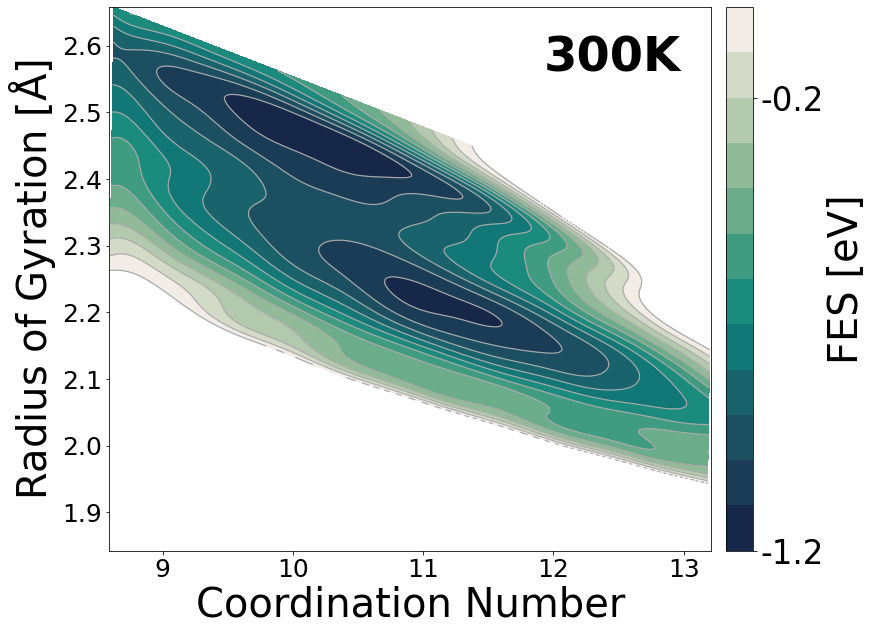

In [15]:
plotting_fes_db()

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

<class 'list'>


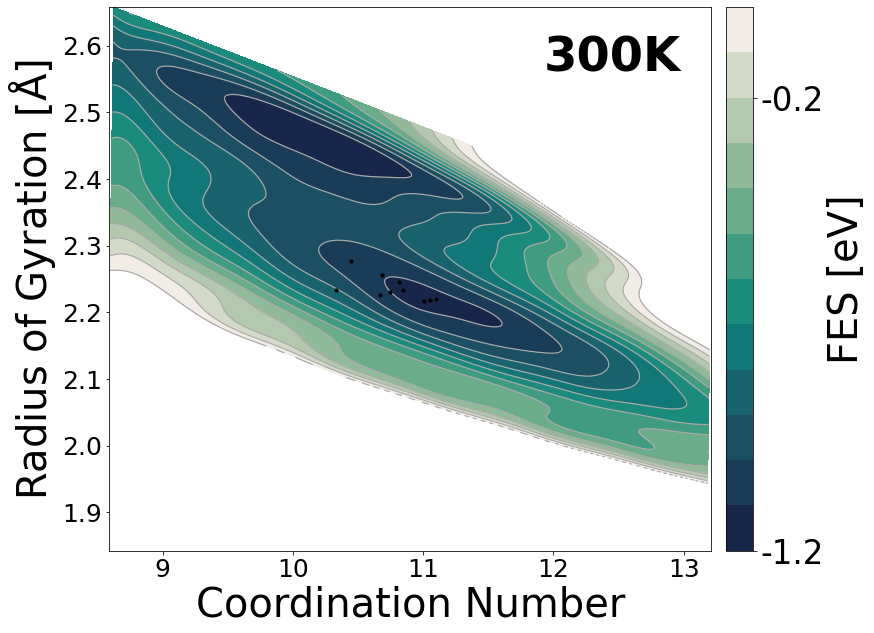

In [29]:
cvs = np.array(get_CVs(zmat[:10,:12])).T
plotting_fes_db()
plt.scatter(cvs[:,0], cvs[:,1], c='k', s=10, zorder=10)

<class 'list'>


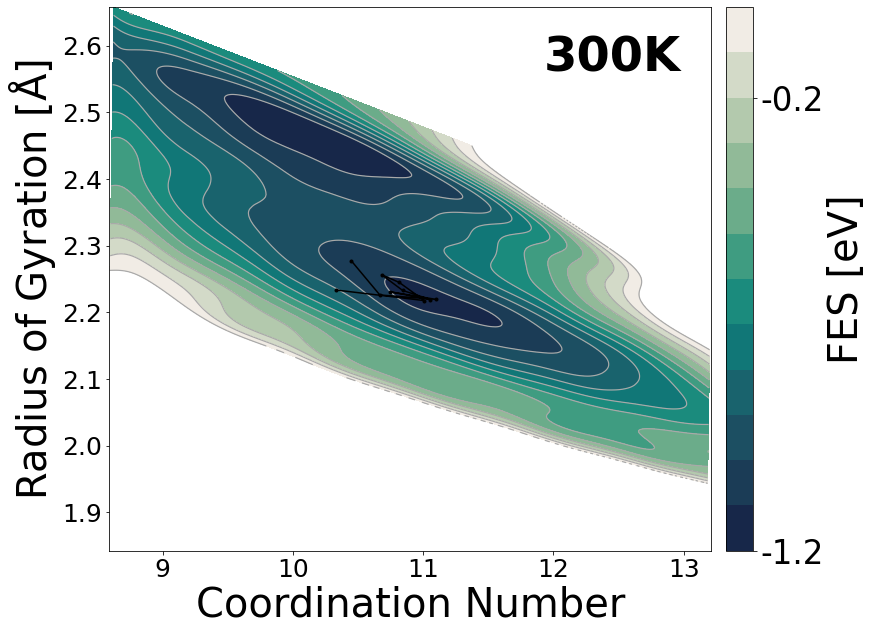

In [60]:
plotting_fes_db()
plt.plot(cvs[:,0], cvs[:,1], '.-', c='k', zorder=10)

In [30]:
n = 100
# md samples

x0_train_cv = np.array(get_CVs(zmats[0][:n, :12])).T
#x1_test_cvs = np.array(get_CVs(zmats_test[0][:n, :12])).T

x1_train_cv = np.array(get_CVs(zmats[1][:n, :12])).T
#x2_test_cvs = np.array(get_CVs(zmats_test[1][:n, :12]))).T

# flow samples

x0_sample = coord_mapping.get_internal_from_real_centered(flows[0].sample(n), isomer=0)[0]
x0_sample_cv = np.array(get_CVs(x0_sample)).T

x1_sample = coord_mapping.get_internal_from_real_centered(flows[1].sample(n), isomer=1)[0]
x1_sample_cv = np.array(get_CVs(x1_sample)).T

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

<class 'list'>


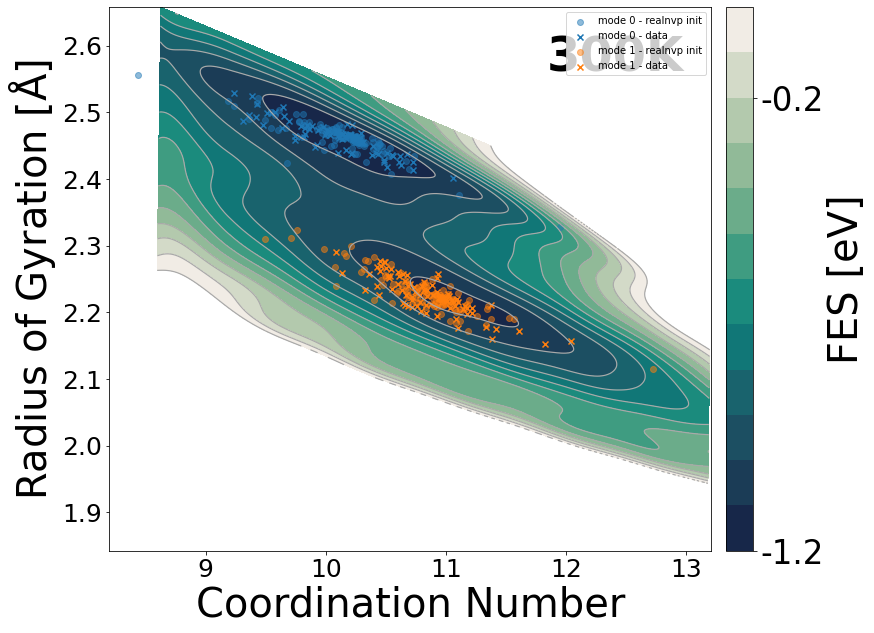

In [31]:
fig, ax = plotting_fes_db()
ax.scatter(x0_sample_cv[:, 0], x0_sample_cv[:, 1], label="mode {:d} - realnvp init".format(0), c='C{:d}'.format(0), alpha=0.5)
ax.scatter(x0_train_cv[:, 0], x0_train_cv[:, 1], marker='x', c='C{:d}'.format(0), label="mode {:d} - data".format(0))
ax.scatter(x1_sample_cv[:, 0], x1_sample_cv[:, 1], label="mode {:d} - realnvp init".format(1), c='C{:d}'.format(1), alpha=0.5)
ax.scatter(x1_train_cv[:, 0], x1_train_cv[:, 1], marker='x', c='C{:d}'.format(1), label="mode {:d} - data".format(1))
ax.legend()
plt.show()

<class 'list'>


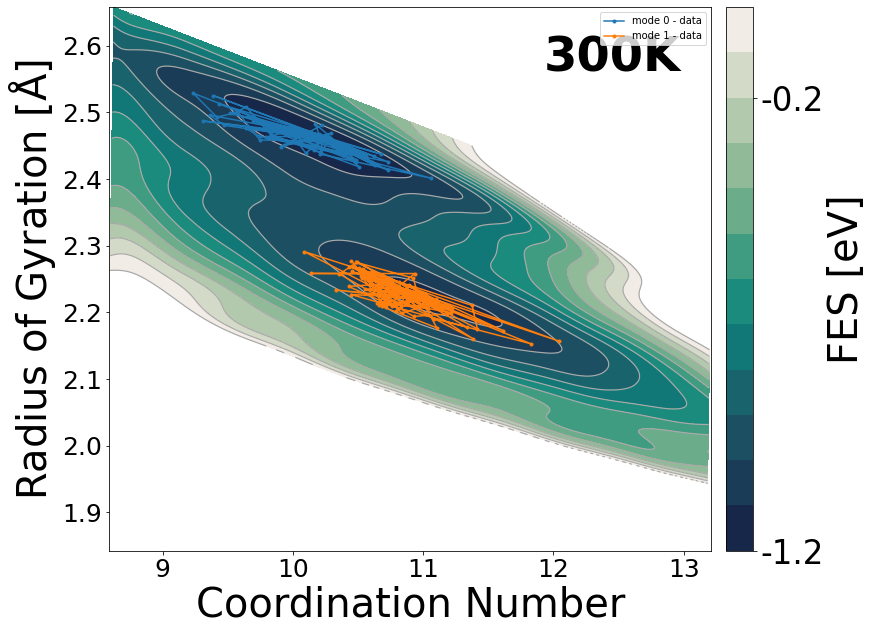

In [61]:
fig, ax = plotting_fes_db()
# ax.scatter(x0_sample_cv[:, 0], x0_sample_cv[:, 1], label="mode {:d} - realnvp init".format(0), c='C{:d}'.format(0), alpha=0.5)
ax.plot(x0_train_cv[:, 0], x0_train_cv[:, 1], '.-', c='C{:d}'.format(0), label="mode {:d} - data".format(0))
# ax.scatter(x1_sample_cv[:, 0], x1_sample_cv[:, 1], label="mode {:d} - realnvp init".format(1), c='C{:d}'.format(1), alpha=0.5)
ax.plot(x1_train_cv[:, 0], x1_train_cv[:, 1], '.-', c='C{:d}'.format(1), label="mode {:d} - data".format(1))
ax.legend()
plt.show()

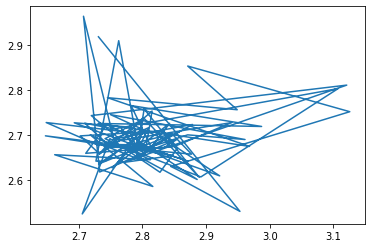

In [63]:
plt.plot(zmats[0][:n, 0].detach(), zmats[0][:n, 1].detach())

# Trying with importance sampling

In [93]:
n_samples = 200 #00

x_sample_cvs = []
log_weightss = []
log_normed_weightss = []

for mode_label in mode_labels:
    x_real_centered = flows[mode_label].sample(n_samples)
    x_zmat = coord_mapping.get_internal_from_real_centered(x_real_centered, isomer=mode_label)[0]
    x_sample_cv = np.array(get_CVs(x_zmat)).T

    # raise Warning("Check the angle mapping and computations of the mean and covariance")
    # Angles_mapping().mapping(xs)
    log_weights = (- beta * mlps[mode_label](x_real_centered).squeeze() - flows[mode_label].nll(x_real_centered)).detach().numpy()
    log_normed_weights = log_weights - logsumexp(log_weights)
    normed_weights = np.exp(log_normed_weights)

    x_sample_cvs.append(x_sample_cv)
    log_normed_weightss.append(log_normed_weights)
    log_weightss.append(log_weights)



/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

<class 'list'>


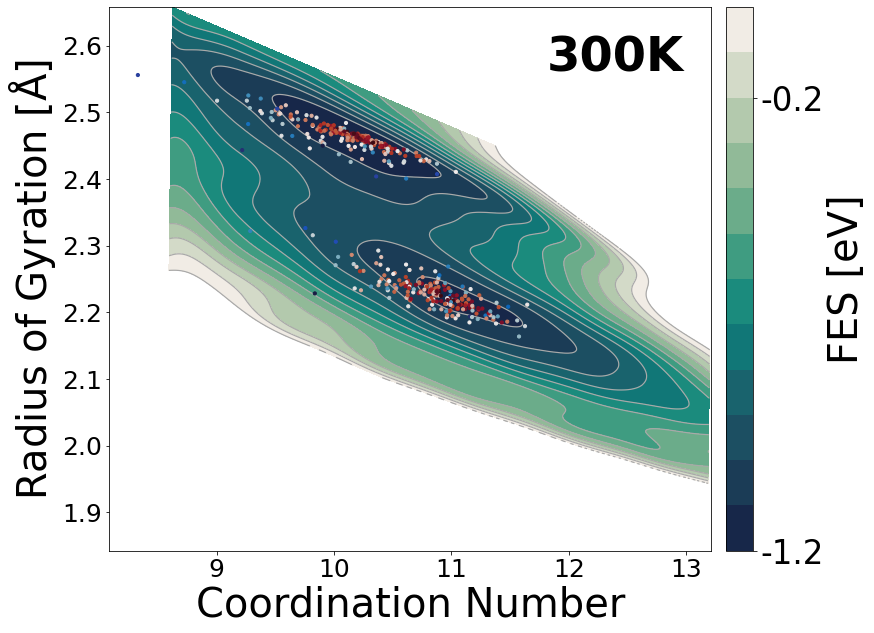

In [108]:
fig, ax = plotting_fes_db()
for mode_label in mode_labels:
    ax.scatter(x_sample_cvs[mode_label][:, 0], x_sample_cvs[mode_label][:, 1], c=log_normed_weightss[mode_label],
               cmap=cmo.balance, s=10, zorder=10)

# plt.colorbar()

In [144]:
np.save('samples_from_flow.npy',np.array(x_sample_cvs))


In [148]:
np.save('logweights.npy',np.array(log_normed_weightss))

In [95]:
# equals one if all participate - equal 1/n_samples if one only participate
normed_part_ratio = normed_weights.sum() / (normed_weights ** 2).sum() / n_samples 
normed_part_ratio

0.04881165027618408

<class 'list'>
<class 'list'>


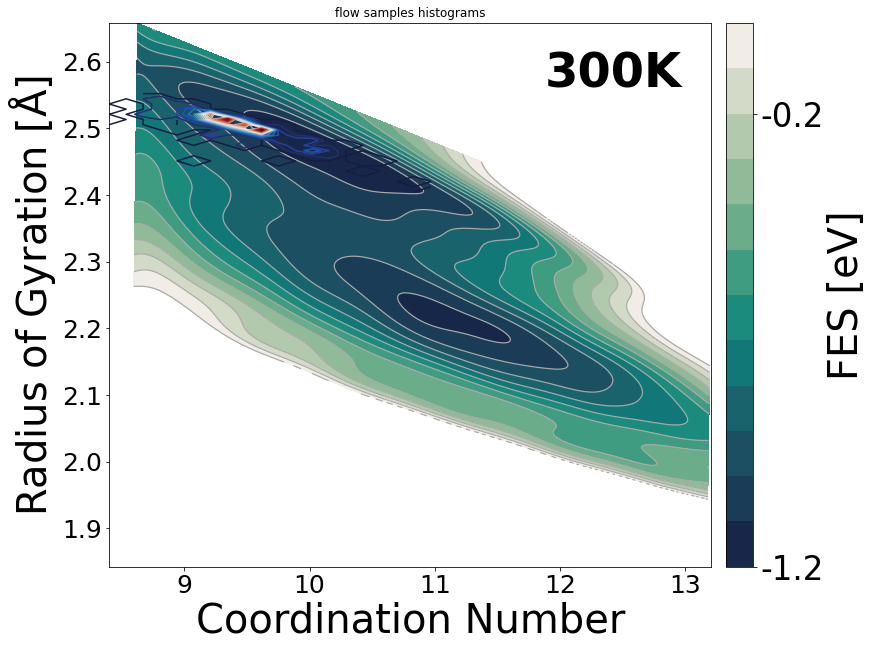

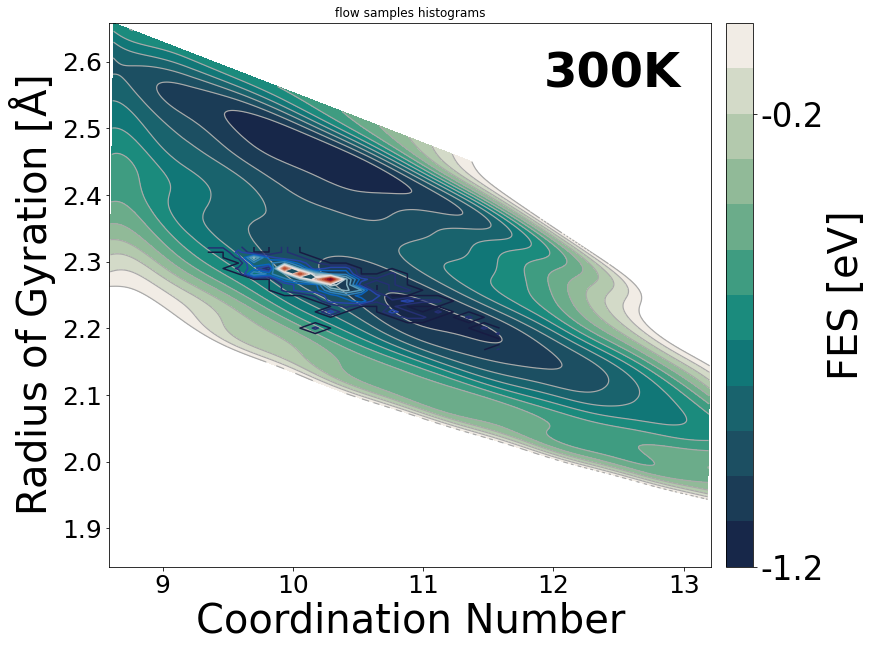

In [109]:
for mode_label in mode_labels:
    out = np.histogram2d(x_sample_cvs[mode_label][:,0], x_sample_cvs[mode_label][:,1], bins=20) # weights=np.exp(log_normed_weightss[mode_label]))
    hist, xedges, yedges = out
    xpos = 0.5 * (xedges[:-1]+xedges[1:])
    ypos = 0.5 * (yedges[:-1]+yedges[1:])
    
    fig, ax = plotting_fes_db()
    plt.title('flow samples histograms')
    plt.contour(xpos, ypos, hist, 20, cmap=cmo.balance)

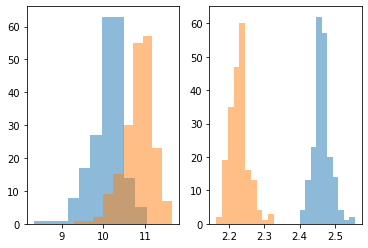

In [106]:
plt.figure()
axes = [plt.subplot(1,2,1), plt.subplot(1,2,2)]
for mode_label in mode_labels:
    axes[0].hist(x_sample_cvs[mode_label][:,0], alpha=0.5)
    axes[1].hist(x_sample_cvs[mode_label][:,1], alpha=0.5)


<class 'list'>
<class 'list'>


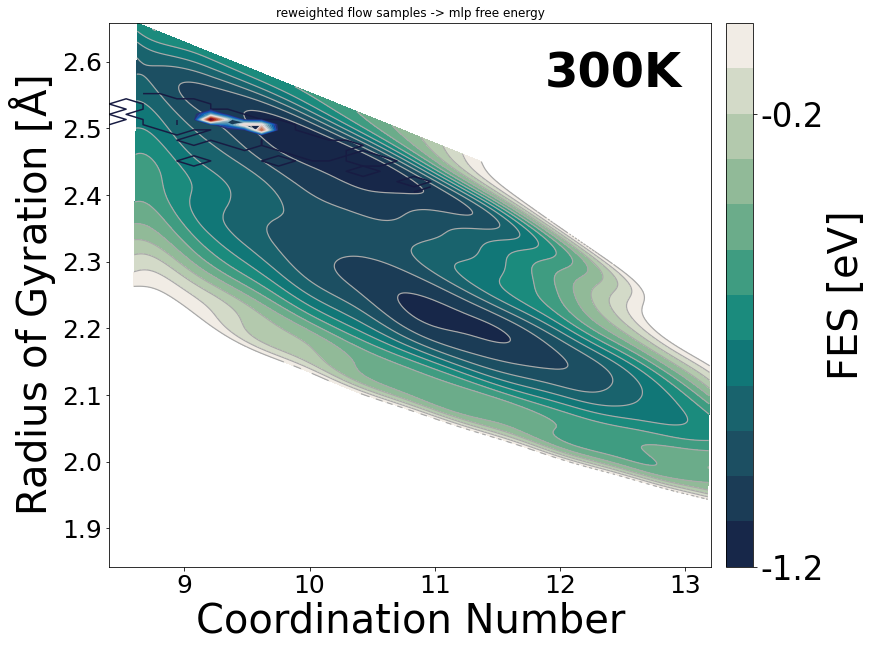

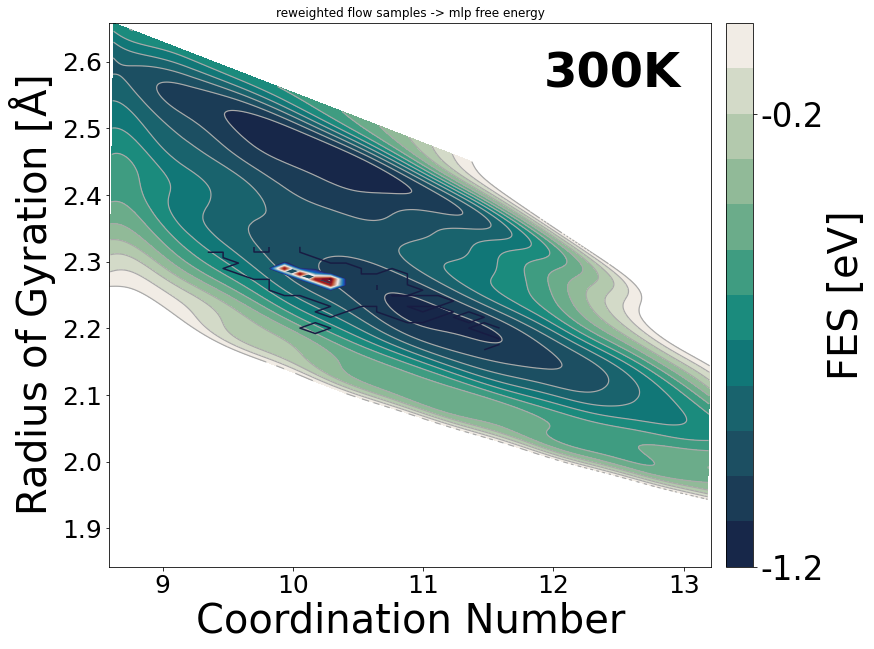

In [116]:
for mode_label in mode_labels:
    out = np.histogram2d(x_sample_cvs[mode_label][:,0], x_sample_cvs[mode_label][:,1], bins=20, weights=np.exp(log_normed_weightss[mode_label]))
    hist, xedges, yedges = out
    xpos = 0.5 * (xedges[:-1]+xedges[1:])
    ypos = 0.5 * (yedges[:-1]+yedges[1:])
    
    fig, ax = plotting_fes_db()
    plt.title('reweighted flow samples -> mlp free energy')
    plt.contour(xpos, ypos, hist, 20, cmap=cmo.balance)

(array([189.,   5.,   1.,   0.,   0.,   0.,   1.,   1.,   2.,   1.]),
 array([3.69157287e-16, 1.69313885e-02, 3.38627771e-02, 5.07941619e-02,
        6.77255541e-02, 8.46569389e-02, 1.01588324e-01, 1.18519716e-01,
        1.35451108e-01, 1.52382493e-01, 1.69313878e-01]),
 <BarContainer object of 10 artists>)

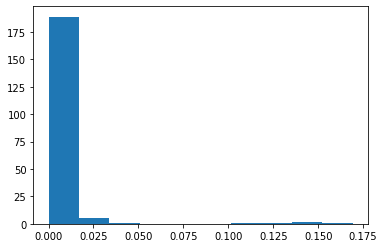

In [115]:
plt.hist(np.exp(log_normed_weightss[mode_label]))

# Superposing tabulated minima

In [65]:
zmat_minimas = []
for mode_label in mode_labels:
    zmat_minimas.append(coord_mapping.zmat_minima[mode_label])
cvs_minimas = np.array(get_CVs(zmat_minimas)).T

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

<class 'list'>
<class 'list'>


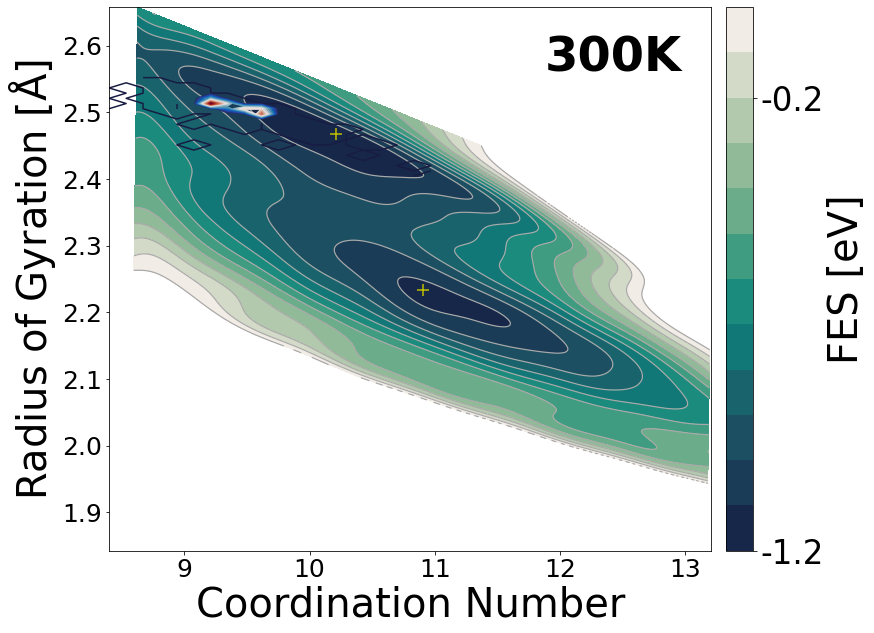

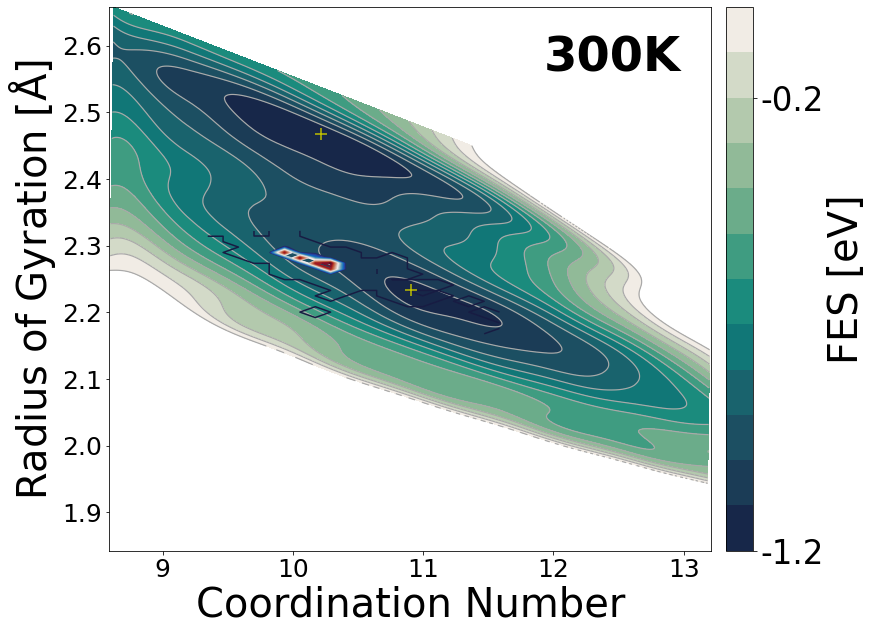

In [110]:
for mode_label in mode_labels:
    out = np.histogram2d(x_sample_cvs[mode_label][:,0], x_sample_cvs[mode_label][:,1], bins=20, weights=np.exp(log_normed_weightss[mode_label]))
    hist, xedges, yedges = out
    xpos = 0.5 * (xedges[:-1]+xedges[1:])
    ypos = 0.5 * (yedges[:-1]+yedges[1:])
    
    fig, ax = plotting_fes_db()
    plt.contour(xpos, ypos, hist, 20, cmap=cmo.balance)
    plt.scatter(cvs_minimas[:,0], cvs_minimas[:,1], marker='+', c='y', s=150, zorder=10)

# Superposing the MLP gd-minima

In [134]:
# minimize the MLP energy
n_chains = 10
x = flows[mode_label].sample(n_chains).detach().requires_grad_(True)
optimizer = torch.optim.Adam([x], lr=1e-3)
losses = []
xs = []
max_iter = 1000
for i in range(max_iter):
    optimizer.zero_grad()
    loss_chains = mlps[mode_label](x).squeeze()
    loss = loss_chains.sum()
    loss.backward()
    optimizer.step()

    losses.append(loss_chains.detach().numpy())

    if i % (max_iter // 10) == 0:
        print(i, loss.item())
        xs.append(x.detach().clone())


0 -67.10873413085938
100 -67.8916244506836
200 -68.04218292236328
300 -68.08219146728516
400 -68.09507751464844
500 -68.09939575195312
600 -68.1015396118164
700 -68.10246276855469
800 -68.1031494140625
900 -68.10368347167969


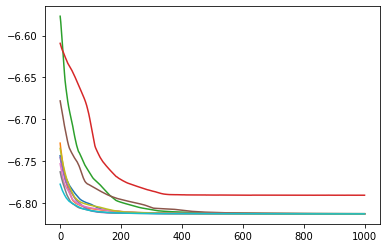

In [135]:
plt.plot(losses)

In [136]:
xs_flat = torch.stack(xs).reshape(-1, 12)
zmat_xs_flat = coord_mapping.get_internal_from_real_centered(xs_flat, isomer=mode_label)[0]
cvs_xs_flat = np.array(get_CVs(zmat_xs_flat),).T
cvs_xs = cvs_xs_flat.reshape(-1, n_chains, 2)

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

<class 'list'>


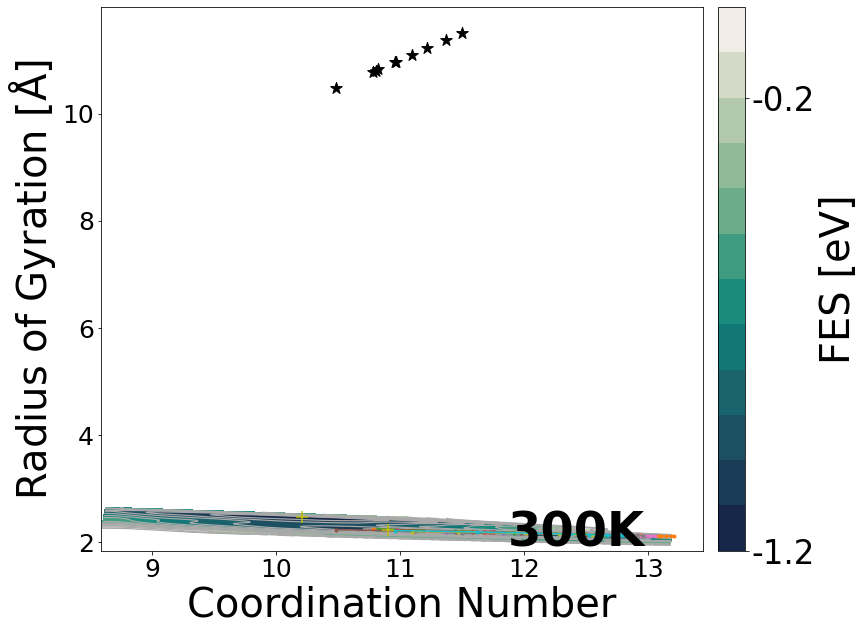

In [139]:
plotting_fes_db()
n_chains = n
for i in range(n_chains):
    plt.plot(cvs_xs[:,i,0], cvs_xs[:,i,1], '.-')
plt.scatter(cvs_minimas[:,0], cvs_minimas[:,1], marker='+', c='y', s=150, zorder=10) 
plt.scatter(cvs_xs[0,:,0], cvs_xs[0,:,0], marker='*', c='k', s=150, zorder=10)

In [127]:
cvs_xs.shape

(10, 10, 2)

In [133]:
cvs_xs[:,2,1]

array([2.13583411, 2.13583411, 2.13583411, 2.13583411, 2.13583411,
       2.13583411, 2.13583411, 2.13583411, 2.13583411, 2.13583411])